# Laboratorio Teoría de Modelos y simulación de sistemas
## Capítulo 3. Datos

### 3.1. Generación de señales

La generación de señales resulta bastante importante a la hora de simular sistemas dinámicos. Para crearlas, manipularlas y visualizarlas, Python cuenta con librerías como Numpy (Capítulo 1), Matplotlib (Capítulo 2) y SciPy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

**Ejemplo 1:** Construir un vector con los enteros comprendidos entre 0 y 6.

In [2]:
t = np.arange(7)
print(t)

[0 1 2 3 4 5 6]


**Ejemplo 2:** Construir un vector de 2 a 6 con pasos de 0,5. Para generar incrementos diferentes a la unidad, se ingresa un tercer parámetro para indicar el valor del paso.

In [3]:
t = np.arange(2, 6.5, 0.5) # ¿Por qué se coloca 6.5 y no 6? Ver documentación.
print(t)

[2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]


Si en lugar de determinar el paso del incremento se necesita tener un número de elementos igualmente espaciados, se utiliza el comando `linspace`.

In [4]:
t2 = np.linspace(2, 6, 15)
# Sintaxis: np.linspace(inicio, fin, número de elementos).
# Note que es muy diferente a la sintaxis de np.arange()
print(t2)

[2.         2.28571429 2.57142857 2.85714286 3.14285714 3.42857143
 3.71428571 4.         4.28571429 4.57142857 4.85714286 5.14285714
 5.42857143 5.71428571 6.        ]


**Ejemplo 3:** Generar una señal parabólica unitaria de 2 segundos de duración y un periodo de muestreo de 0.1 segundos.

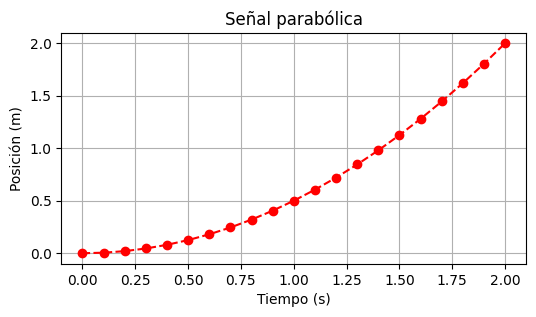

In [5]:
t = np.arange(0, 2.1, 0.1)
y = (1/2)*t**2
plt.figure(figsize=(6, 3))
plt.plot(t, y, '--ro')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición (m)')
plt.title('Señal parabólica')
plt.grid()

**Ejemplo 4:** Construir una señal de amplitud 4 y frecuencia 20 rad/s a partir del vector de tiempo anterior. Graficar como señal discreta.

Text(0.5, 1.0, 'Señal senoidal')

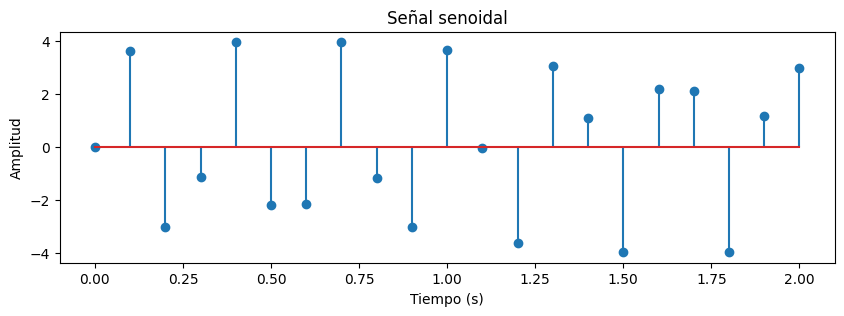

In [6]:
t = np.arange(0, 2.1, 0.1)
y = 4 * np.sin(20*t)
plt.figure(figsize=(10, 3))
plt.stem(t,y)
# Se utiliza la función stem() para graficar señales discretas
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal senoidal')

Como se observa en la figura y en los resultados numéricos, los cambios en los valores son muy bruscos ya que el periodo de muestreo (0.1 segundos) es muy grande comparado con la frecuencia de la señal. Es por esto que la gráfica anterior no tiene la forma senoidal esperada. Para solucionarlo, se puede disminuir el periodo de muestreo a 0.02 segundos.

Text(0.5, 1.0, 'Señal senoidal')

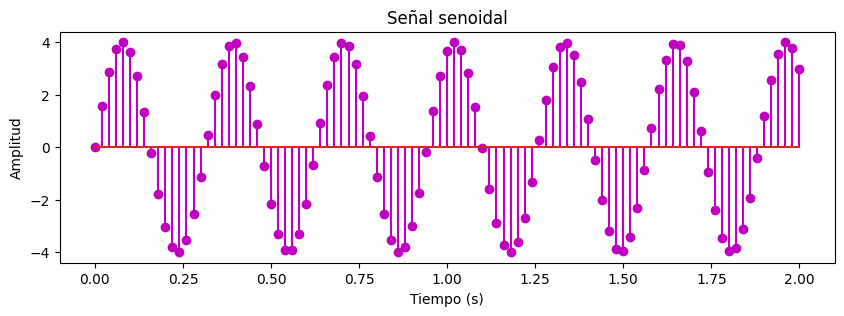

In [7]:
t = np.arange(0, 2.002, 0.02)
y = 4 * np.sin(20*t)
plt.figure(figsize=(10, 3))
plt.stem(t,y, '-m')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal senoidal')

### 3.2. Análisis de datos

En Python se puede realizar análisis de datos estadística o probabilísticamente. Entre estos análisis están los cálculos de medias, máximos, mínimos, desviaciones estándar, entre otros.

Considere la matriz X:

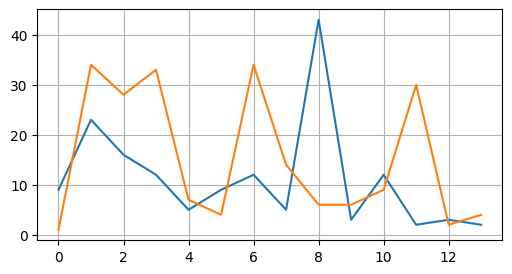

In [8]:
X = np.array([[9,1],[23, 34], [16, 28], [12,33],[5,7],[9, 4],
  [12, 34], [5, 14], [43, 6], [3, 6], [12, 9],
  [2, 30], [3, 2], [2, 4]])
# Visualización de las dos columnas de X
fig = plt.figure(figsize=(6, 3))
plt.plot(X)
plt.grid()

**Ejercicio 1:** Calcular el promedio, la desviación estándar, el valor máximo y el valor mínimo de las dos columnas de X. Además, graficar el histograma para representar la distribución de los datos en ambas columnas.

Promedio de cada columna: [11.14285714 15.14285714]
Desviación estándar de cada columna: [10.57528887 12.84443817]
Máximo de cada columna: [43 34]
Mínimo de cada columna: [2 1]


Text(0, 0.5, 'Cantidad')

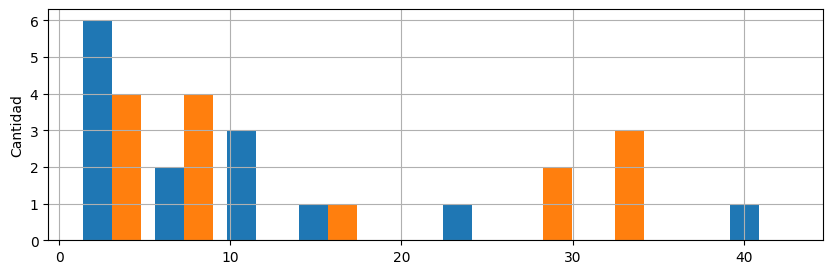

In [9]:
mean = np.mean(X, axis=0)
print("Promedio de cada columna:", mean)
desv = np.std(X, axis=0)
print("Desviación estándar de cada columna:", desv)
max_values = np.max(X, axis=0)
print("Máximo de cada columna:", max_values)
min_values = np.min(X, axis=0)
print("Mínimo de cada columna:", min_values)
plt.figure(figsize=(10, 3))
plt.hist(X)
plt.grid()
plt.ylabel('Cantidad')

### 3.3. Ajuste de tendencia

Al procesar datos, puede resultar útil identificar tendencias y encontrar la curva que mejor se ajusta a los datos disponibles.

**Ejemplo 1:** Se tienen los datos que corresponden a un instante de tiempo. Encontrar el ajuste cuadrático y cúbico.

[-0.63869464  1.27142191  0.02237762]
[-2.04739705  2.43240093  0.1003108   0.09608392]


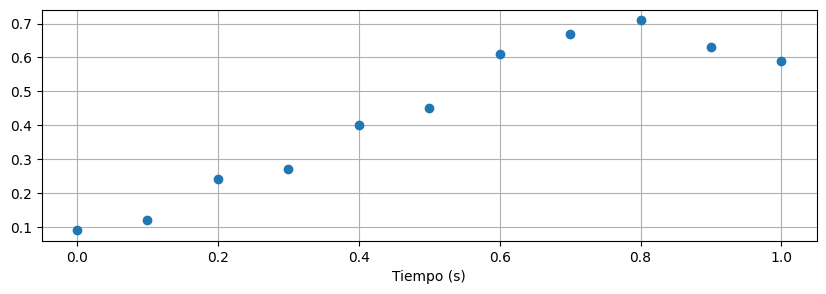

In [10]:
t = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
y = np.array([0.09, 0.12, 0.24, 0.27, 0.4, 0.45, 0.61, 0.67, 0.71, 0.63, 0.59])
# Exploración de los datos
plt.figure(figsize=(10, 3))
plt.plot(t, y, 'o')
plt.grid()
plt.xlabel('Tiempo (s)')
p2 = np.polyfit(t, y, 2) # Ajuste polinómico de grado 2
p3 = np.polyfit(t, y, 3) # Ajuste polinómico de grado 3
print(p2)
print(p3)
# ¿Qué información se obtiene de p2 y p3?
y2_fit = np.polyval(p2, t)
y3_fit = np.polyval(p3, t)

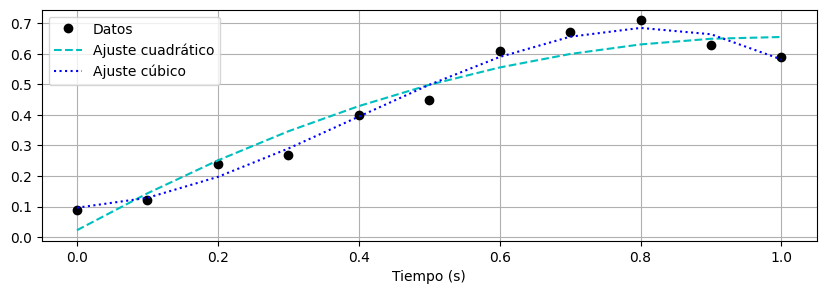

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(t, y, 'ok', label='Datos')
plt.plot(t, y2_fit, '--c', label='Ajuste cuadrático')
plt.plot(t, y3_fit, ':b', label='Ajuste cúbico')
plt.xlabel('Tiempo (s)')
plt.grid()
plt.legend()